<a href="https://colab.research.google.com/github/jessikawq/ModelosAnaliticosUnicafam202607/blob/main/Parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#PASO 1. Importar todas las librerias
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
dataset = pd.read_excel('/content/sample_data/crime_data.xlsx')

In [5]:
# Le cambiamos el nombre a la primera columna para que sea más claro
dataset = dataset.rename(columns={'Unnamed: 0': 'Estado'})

In [7]:
X = dataset.iloc[:, [1, 2, 3, 4]].values

In [8]:
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

In [9]:
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_escalado)

In [10]:
dataset['Grupo'] = y_kmeans

In [11]:
print(dataset.groupby('Grupo').mean(numeric_only=True))

          Murder     Assault   UrbanPop       Rape
Grupo                                             
0       4.734483  111.827586  64.103448  15.820690
1      13.937500  243.625000  53.750000  21.412500
2      10.815385  257.384615  76.000000  33.192308


In [12]:
print("\nCantidad de estados por grupo:")
print(dataset['Grupo'].value_counts())


Cantidad de estados por grupo:
Grupo
0    29
2    13
1     8
Name: count, dtype: int64


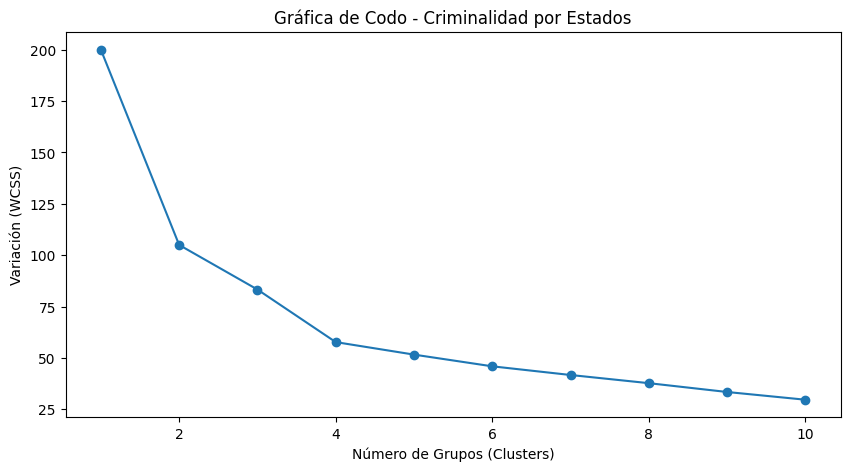

In [13]:
wcss = []
# Probamos hacer desde 1 hasta 10 grupos
for i in range(1, 11):
    kmeans_codo = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans_codo.fit(X_escalado) # Usamos los datos escalados
    wcss.append(kmeans_codo.inertia_)

# Dibujamos la línea
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o') # marker='o' le pone un puntito a cada doblez
plt.title('Gráfica de Codo - Criminalidad por Estados')
plt.xlabel('Número de Grupos (Clusters)')
plt.ylabel('Variación (WCSS)')
plt.show()

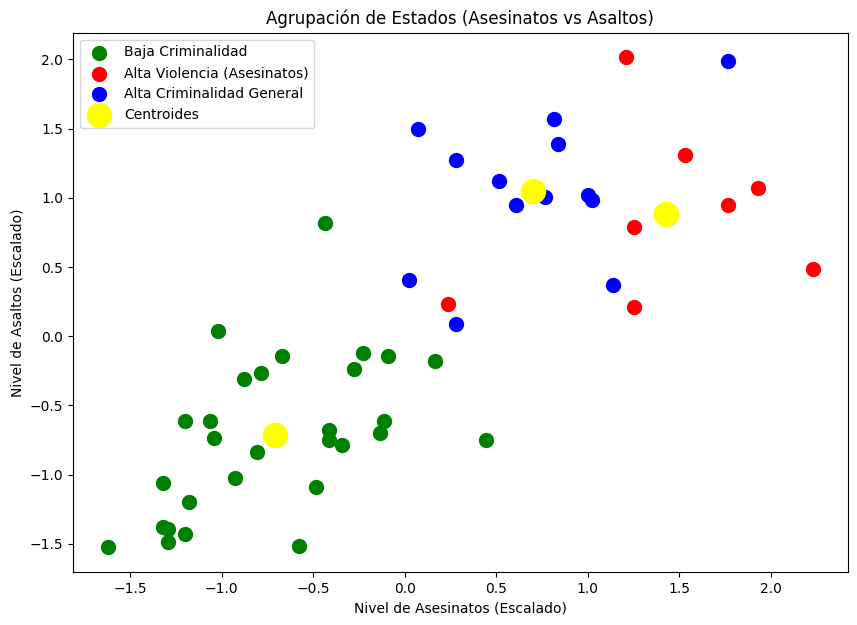

In [14]:
# ==========================================
# GRÁFICA 2: VISUALIZACIÓN DE LOS GRUPOS
# ==========================================
plt.figure(figsize=(10, 7))

# Grupo 0 (Baja criminalidad) - Color Verde
plt.scatter(X_escalado[y_kmeans == 0, 0], X_escalado[y_kmeans == 0, 1], s=100, c='green', label='Baja Criminalidad')

# Grupo 1 (Alta violencia / Asesinatos) - Color Rojo
plt.scatter(X_escalado[y_kmeans == 1, 0], X_escalado[y_kmeans == 1, 1], s=100, c='red', label='Alta Violencia (Asesinatos)')

# Grupo 2 (Alta criminalidad en general / Asaltos) - Color Azul
plt.scatter(X_escalado[y_kmeans == 2, 0], X_escalado[y_kmeans == 2, 1], s=100, c='blue', label='Alta Criminalidad General')

# Dibujar los Centroides (El corazón de cada grupo) - Color Amarillo
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroides')

# Títulos y etiquetas del plano
plt.title('Agrupación de Estados (Asesinatos vs Asaltos)')
plt.xlabel('Nivel de Asesinatos (Escalado)')
plt.ylabel('Nivel de Asaltos (Escalado)')
plt.legend() # Muestra el cuadrito con los nombres de los colores
plt.show()

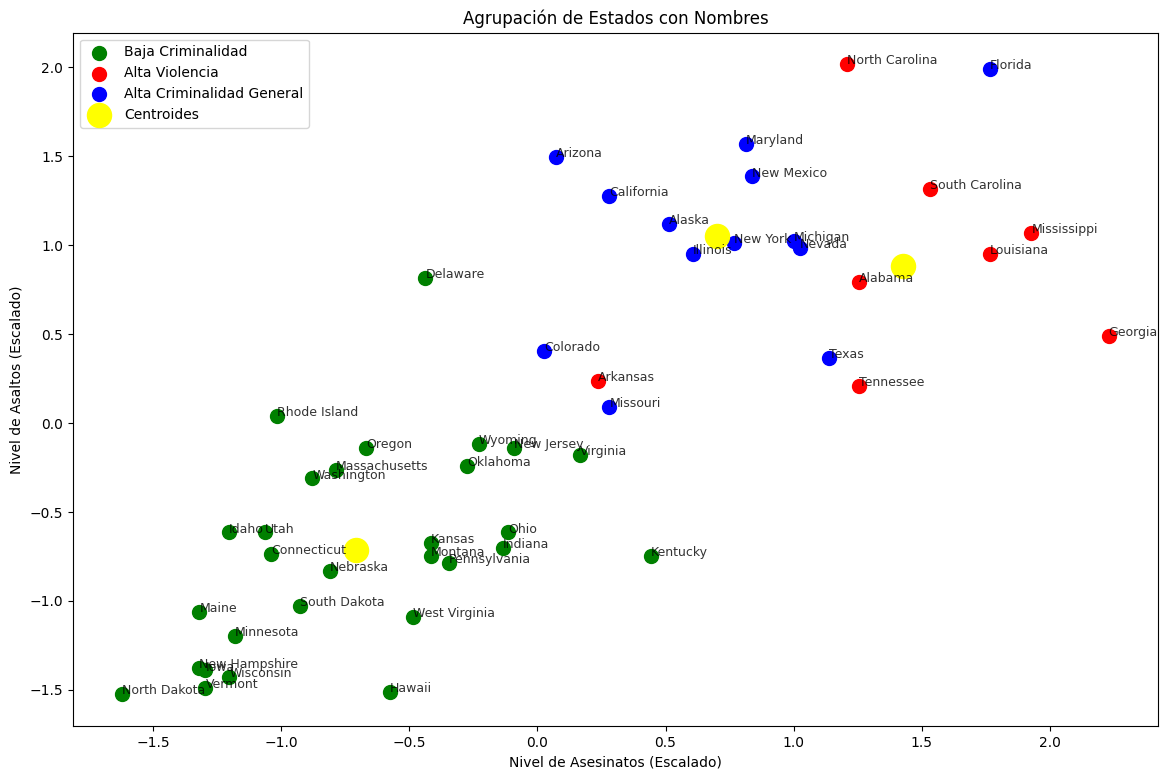

In [15]:
plt.figure(figsize=(14, 9)) # Hicimos el lienzo más grande (14x9) para que quepan los nombres

# Dibujamos los puntos igual que antes
plt.scatter(X_escalado[y_kmeans == 0, 0], X_escalado[y_kmeans == 0, 1], s=100, c='green', label='Baja Criminalidad')
plt.scatter(X_escalado[y_kmeans == 1, 0], X_escalado[y_kmeans == 1, 1], s=100, c='red', label='Alta Violencia')
plt.scatter(X_escalado[y_kmeans == 2, 0], X_escalado[y_kmeans == 2, 1], s=100, c='blue', label='Alta Criminalidad General')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='yellow', label='Centroides')

# ==========================================
# EL TRUCO PARA PONER LOS NOMBRES
# ==========================================
# Le decimos a Python: "recorre la columna 'Estado' uno por uno..."
for i, nombre_estado in enumerate(dataset['Estado']):
    # "...y pon ese nombre en la coordenada exacta de su punto correspondiente"
    plt.annotate(nombre_estado, (X_escalado[i, 0], X_escalado[i, 1]), fontsize=9, alpha=0.8)

# Títulos y mostrar
plt.title('Agrupación de Estados con Nombres')
plt.xlabel('Nivel de Asesinatos (Escalado)')
plt.ylabel('Nivel de Asaltos (Escalado)')
plt.legend()
plt.show()

In [16]:
# Mostrar qué estados quedaron en el Grupo 0 (Verdes)
print("=== GRUPO 0 (Baja Criminalidad - Enviar Cadetes) ===")
estados_grupo_0 = dataset[dataset['Grupo'] == 0]['Estado'].tolist()
print(estados_grupo_0)
print("\n") # Esto es solo para dejar un espacio en blanco

# Mostrar qué estados quedaron en el Grupo 1 (Rojos)
print("=== GRUPO 1 (Alta Violencia - Enviar Profesionales) ===")
estados_grupo_1 = dataset[dataset['Grupo'] == 1]['Estado'].tolist()
print(estados_grupo_1)
print("\n")

# Mostrar qué estados quedaron en el Grupo 2 (Azules)
print("=== GRUPO 2 (Alta Criminalidad Urbana - Enviar Policías de a pie) ===")
estados_grupo_2 = dataset[dataset['Grupo'] == 2]['Estado'].tolist()
print(estados_grupo_2)

=== GRUPO 0 (Baja Criminalidad - Enviar Cadetes) ===
['Connecticut', 'Delaware', 'Hawaii', 'Idaho', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Maine', 'Massachusetts', 'Minnesota', 'Montana', 'Nebraska', 'New Hampshire', 'New Jersey', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Dakota', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


=== GRUPO 1 (Alta Violencia - Enviar Profesionales) ===
['Alabama', 'Arkansas', 'Georgia', 'Louisiana', 'Mississippi', 'North Carolina', 'South Carolina', 'Tennessee']


=== GRUPO 2 (Alta Criminalidad Urbana - Enviar Policías de a pie) ===
['Alaska', 'Arizona', 'California', 'Colorado', 'Florida', 'Illinois', 'Maryland', 'Michigan', 'Missouri', 'Nevada', 'New Mexico', 'New York', 'Texas']
